Librerías y Funciones propias:

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt
from helpers.room import room
from helpers.generateRirs import generateRirs
from helpers.perturbSecondaryPath import perturbSecondaryPath

Simulation:

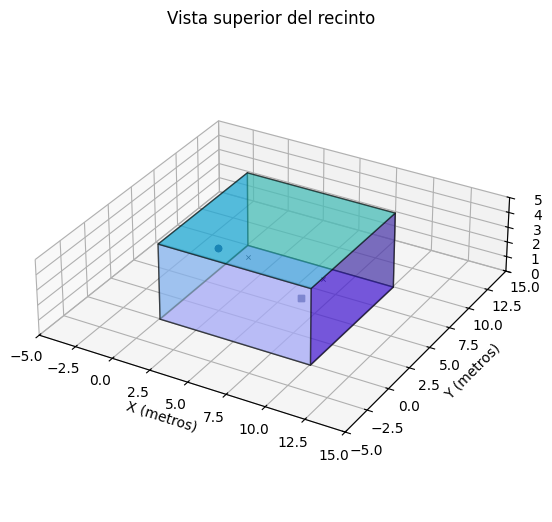

In [3]:
fs = 48000
room = room(fs)

Obtain RIRs:

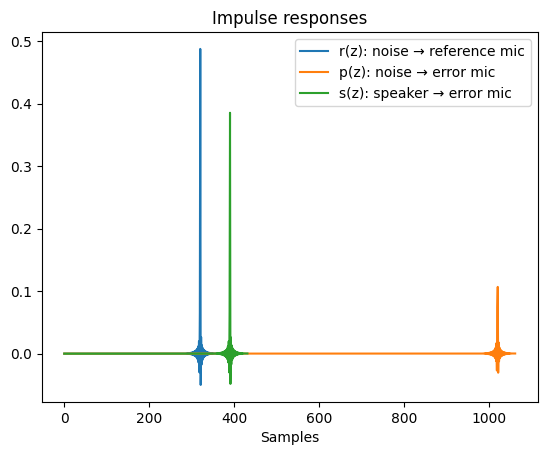

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [4]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

Internoise 2023: 

This is an implementation of the algorithm for online secondary path modelling presented in the internoise 2023 paper "A Computation-efficient Online Secondary Path Modeling Technique for Modified FXLMS Algorithm" by Ji et al. The algorithm switches between MFxLMS and the SPM algorithm based on a divergence detection. 

The SPM algorithm is designed to track small changes in the plant response, so it will be tested by swapping the plant response at a certain block and will initialize with an accurate model of the first plant response. The algorithm only adapts the secondary path, but one of its advantages is it keeps the controller activated as it models changes in S(Z), allowing for some noise cancelling during this process, so the statitc W(z) is initialized with appropriately converged coefficients.

The following code obtains the filter coefficients:

In [26]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 1000
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 25
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sPectrumOriginal = sSpectrum.copy()
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)
mean_e_p_hist = np.zeros(nBlocks)

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    
    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fyBlockOutput)

    e = pBlockOutput - fyBlockOutput

    # Reconstruct desired signal 
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)
    sHatPrimeOutputBlocks.append(yPrimeBlockOutput)

    dHat = e + yPrimeBlockOutput

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)
    wHatOutputBlocks.append(yHatBlockOutput)

    eHat = dHat - yHatBlockOutput

    # LMS algorithm
    w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, mu)

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e

The SPM algorithm:

-0.02422163714894981
-0.024528469610714466
-0.024195814414503344
-0.02407574774948492
-0.024072014462532237
-0.02439386613328352
-0.02467554586973517
-0.024833944145837242
-0.024987432643127073
-0.025299926270141646
-0.025645778808861024
-0.02644533214662506
-0.027277701536346968
-0.02773894504777616
-0.028202377892318366
-0.029013055345772053
-0.030027301075170543
-0.03125520860029455
-0.03242473748854219
-0.03330547331382949
-0.03419592920714071
-0.034647283071872405
-0.0355013098892345
-0.03602000357163044
-0.03636719164269748
-0.036542359896775796
-0.03671283556171065
-0.03678415636515877
-0.0364227097060732
-0.03598783516910677
-0.035468326022755785
-0.034677031150758736
-0.03409139192321205
-0.033709913473756556
-0.03327446024401192
-0.03265811641864685
-0.031991210247092144
-0.031087650175716422
-0.030182716626210495
-0.02950187270949703
-0.02891640537046043
-0.028526382111673805
-0.02786744449585832
-0.027273692448348204
-0.026590946116192185
-0.025781531161042204
-0.0251777222

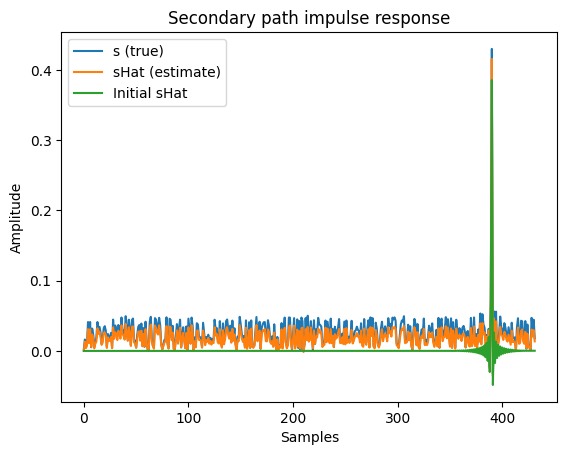

Difference between mean squared value of S(z) and model:  6.335509966063957e-05
Difference between mean squared value of S(z) and initial model:  0.0008245356936779062


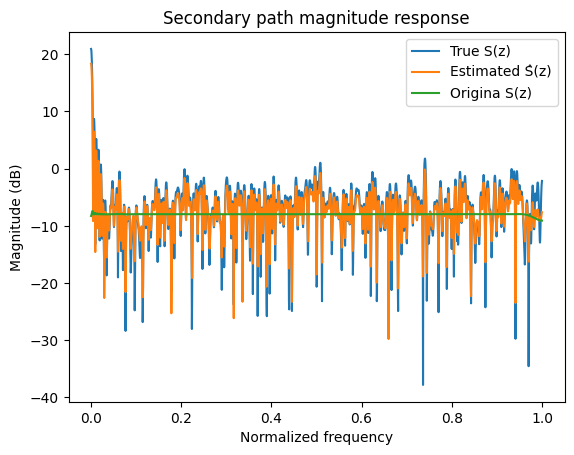

In [27]:
# Reset buffers and output blocks 

# Adaptive filter (it's static so the spectrum can be precalculated)
wSpectrum = np.fft.rfft(w, N_w)
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s.copy()
initialSHat = sHat.copy()
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []
mu = 0.05

# Noise source path
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

#s = perturbSecondaryPath(s, amp=1, phase=0.1)
s = s + 0.05 * np.random.rand(len(s))
sSpectrum = np.fft.rfft(s, N_s)

# Error history
errorHistory = np.zeros(nBlocks)

T21Counter = 0

for k in range(nBlocks):

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)

    # Adaptive filter W(z)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    
    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filter y(n) by the plant model
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)

    dHat = e - yPrimeBlockOutput

    eHat = dHat + yHatBlockOutput

    # Adapt secondary path model (helper function utilizes inverse gradient)
    yBlockOutputPadded = np.concatenate([yBlockOutput, np.zeros(M_sHat - 1)])
    eHatPadded = np.concatenate([eHat, np.zeros(M_sHat - 1)])
    crossCorrelationResult = np.fft.irfft(np.fft.rfft(yBlockOutputPadded, N_sHat).conj() * np.fft.rfft(eHatPadded, N_sHat), N_sHat)
    crossCorrelationResult[M_sHat:] = 0
    crossCorrelationResult = crossCorrelationResult[:M_sHat]
    crossCorrelationResult /= blocklength
    sHat =  sHat - mu * crossCorrelationResult

    # Recalculate sHat spectrum
    sHatSpectrum = np.fft.rfft(sHat, N_sHat)

    blockErrorPower = np.mean(eHat**2)

    if k == 0:
        smoothedError = blockErrorPower
    else:
        smoothedError = 0.99 * smoothedError + (1 - 0.99) * blockErrorPower

    errorHistory[k] = smoothedError

    if k > 2*20:

        mean_recent = np.mean(errorHistory[k-20:k])
        mean_past   = np.mean(errorHistory[k-2*20:k-20])

        T21 = (mean_recent - mean_past) / mean_past

        print(T21)

        if T21 > -0.0001:
            T21Counter += 1
            if T21Counter > 5:
                print("Convergence detected in block :", k)
                break
        else:
            T21Counter = 0

print(errorHistory)


plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.plot(initialSHat, label='Initial sHat')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

print("Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))
print("Difference between mean squared value of S(z) and initial model: ", np.mean((s - initialSHat)**2))

freqs = np.linspace(0,1,len(sHatSpectrum))

plt.figure()
plt.plot(freqs, 20*np.log10(np.abs(sSpectrum)+1e-12), label="True S(z)")
plt.plot(freqs, 20*np.log10(np.abs(sHatSpectrum)+1e-12), label="Estimated Ŝ(z)")
plt.plot(freqs, 20*np.log10(np.abs(sPectrumOriginal)+1e-12), label="Origina S(z)")
plt.title("Secondary path magnitude response")
plt.xlabel("Normalized frequency")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.show()


The full implementation:

T12 detected divergence in block:  20
T12 value:  23.64590724480109
Switching to SPM
T21 detected convergence in block:  66
Difference between mean squared value of S(z) and model:  1.3720256738048355e-06
Switching to ANC...
T12  1  blocks after switching 24.339762207661224
T12  2  blocks after switching 23.853138155284373
T12  3  blocks after switching 24.573943475353985
T12  4  blocks after switching 24.454647177343055
T12  5  blocks after switching 24.8744866411181
T12  6  blocks after switching 25.585563888187266
T12  7  blocks after switching 25.851448726939864
T12  8  blocks after switching 26.079107863875734
T12  9  blocks after switching 26.59223232947056
T12  10  blocks after switching 26.68709736153122
T12  11  blocks after switching 26.921224138485904
T12  12  blocks after switching 27.101824004863346
T12  13  blocks after switching 27.60986365931915
T12  14  blocks after switching 27.80069304970722
T12  15  blocks after switching 27.70896731743165
T12  16  blocks after swit

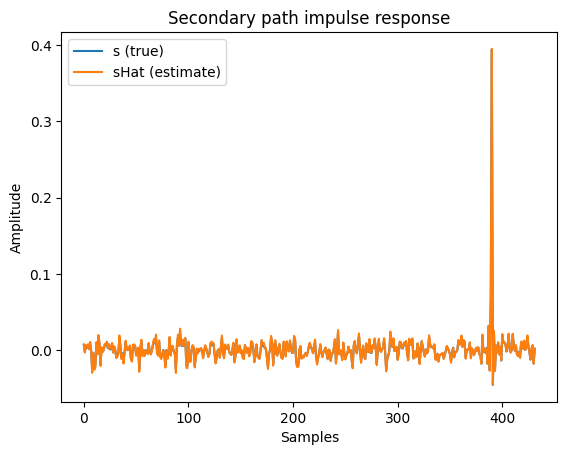

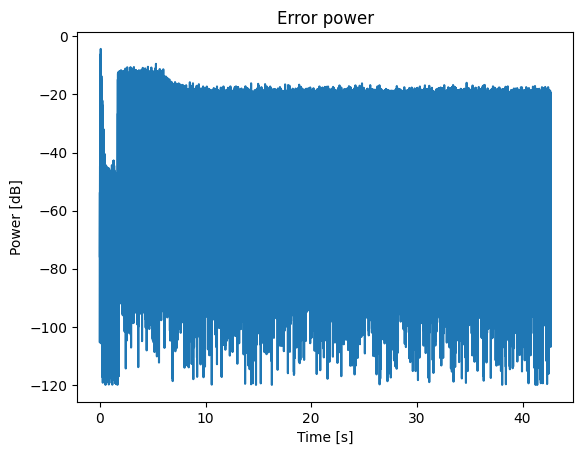

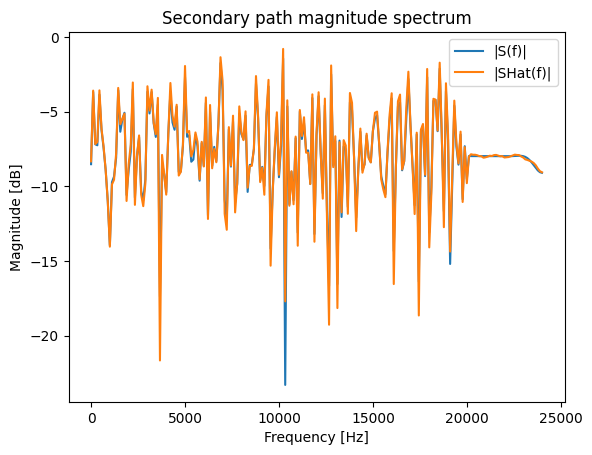

In [6]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
muw = 25
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []
wSpectrum = np.fft.rfft(w, N_w)

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s.copy()
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []
mus = 0.105

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)

# Mode switching
ANC = True
SPM = False

# Initialization for T12 and T21 criterions
errorHistory = np.zeros(nBlocks)
T21Counter = 0
smoothedError = 0
kSwitch = 0

perturbanceMagnitude = 0.01
mus = 0.2
muw = 25
muwAfterSPM = 1
nBlocksAfterSPM = 30
T12Treshold = 30
T12TresholdAfterSPM = 10
breakAfterSPM = False

for k in range(nBlocks):
    # Perturb secondary path
    if k == 20:
        noise = np.random.randn(len(s))
        N = np.fft.rfft(noise)
        f = np.fft.rfftfreq(len(noise), 1/fs)
        N[f > 20000] = 0
        s = s + perturbanceMagnitude * np.fft.irfft(N, len(s))
        sSpectrum = np.fft.rfft(s, N_s)

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)

    # Adaptive filter W(z)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)

    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filter y(n) by the plant model
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)

    # Define if switching to SPM is necessary based on T12 criterion
    if ANC and k > 5:
        Px = np.mean(xBlock**2)
        Pe = np.mean(e**2)

        T12 = 10*np.log10(Px/Pe)

        if  kSwitch < k < (kSwitch + nBlocksAfterSPM) and kSwitch != 0:
            print("T12 " , k - kSwitch , " blocks after switching", T12)

        if T12 < T12Treshold and (kSwitch == 0 or k > (kSwitch + nBlocksAfterSPM)):
            print("T12 detected divergence in block: ", k)
            print("T12 value: ", T12)
            print("Switching to SPM")
            kSwitch = k
            SPM = True
            ANC = False

            # Reset buffers
            wBuffer = np.zeros(M_w - 1)
            wHatBuffer = np.zeros(M_w - 1)
            pBuffer = np.zeros(M_p - 1)
            sBuffer = np.zeros(M_s - 1)
            sHatBuffer = np.zeros(M_sHat - 1)
            sHatPrimeBuffer = np.zeros(M_sHat - 1)
            rBuffer = np.zeros(M_r - 1)

            # Log error before reseting
            e_hist[k * blocklength:(k+1) * blocklength] = e
            continue

    ###################### if ANC is on ###########################
    if ANC:
        dHat = e + yPrimeBlockOutput
        eHat = dHat - yHatBlockOutput

        # Adapt filter
        w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, muw)

        # Recalculate filter spectrum
        wSpectrum = np.fft.rfft(w, N_w)

    ###################### if SPM is on ###########################
    elif SPM:     
        dHat = e - yPrimeBlockOutput
        eHat = dHat + yHatBlockOutput

        # Adapt secondary path model (helper function "adapt" utilizes inverse gradient)
        yBlockOutputPadded = np.concatenate([yBlockOutput, np.zeros(M_sHat - 1)])
        eHatPadded = np.concatenate([eHat, np.zeros(M_sHat - 1)])
        crossCorrelationResult = np.fft.irfft(np.fft.rfft(yBlockOutputPadded, N_sHat).conj() * np.fft.rfft(eHatPadded, N_sHat), N_sHat)
        crossCorrelationResult[M_sHat:] = 0
        crossCorrelationResult = crossCorrelationResult[:M_sHat]
        crossCorrelationResult /= blocklength
        sHat =  sHat - mus * crossCorrelationResult

        # Recalculate sHat spectrum
        sHatSpectrum = np.fft.rfft(sHat, N_sHat)

        # Define if switching to ANC is necessary based on T21 criterion
        blockErrorPower = np.mean(eHat**2)

        if smoothedError == 0:
            smoothedError = blockErrorPower
        else:
            smoothedError = 0.99 * smoothedError + (1 - 0.99) * blockErrorPower

        errorHistory[k] = smoothedError

        if k > kSwitch + 2*20:

            mean_recent = np.mean(errorHistory[k-20:k])
            mean_past   = np.mean(errorHistory[k-2*20:k-20])

            T21 = (mean_recent - mean_past) / mean_past

            if T21 > -0.0001:
                T21Counter += 1
                if T21Counter > 5:
                    print("T21 detected convergence in block: ", k)
                    print("Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))
                    print("Switching to ANC...")
                    kSwitch = k
                    ANC = True
                    SPM = False

                    # Reset buffers
                    wBuffer = np.zeros(M_w - 1)
                    wHatBuffer = np.zeros(M_w - 1)
                    pBuffer = np.zeros(M_p - 1)
                    sBuffer = np.zeros(M_s - 1)
                    sHatBuffer = np.zeros(M_sHat - 1)
                    sHatPrimeBuffer = np.zeros(M_sHat - 1)
                    rBuffer = np.zeros(M_r - 1)

                    if breakAfterSPM:
                        break

                    # Lower muw value
                    muw = muwAfterSPM
                    T12Treshold = T12TresholdAfterSPM
            else:
                T21Counter = 0

    # Error history
    e_hist[k * blocklength:(k+1) * blocklength] = e

print("Final Difference between mean squared value of S(z) and model: ", np.mean((s - sHat)**2))

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

freqs = np.fft.rfftfreq(len(s), 1/fs)
plt.figure()
plt.plot(freqs, 20*np.log10(np.abs(np.fft.rfft(s)) + 1e-12), label='|S(f)|')
plt.plot(freqs, 20*np.log10(np.abs(np.fft.rfft(sHat)) + 1e-12), label='|SHat(f)|')
plt.legend()
plt.title('Secondary path magnitude spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.show()


Further anaylisis of algorithm parameters and how it is affected by different kinds of perturbances should be carried out. Also, since the algorithm only adjusts minor online changes in secondary path, the algorithm in SPM.ipynb could be implemented in order to initially identify the plant offline.

Furthermore, the steady state of the ANC mode worsens after the change in the secondary path, even if the model produced by the SPM is extremely accurate. It should be analyzed in a simulation if this is due to an error in the algorithm of if the MFxLMS algorithm converges to a poorer steady state if the secondary path is coloured. The simulation should firstly evaluate the steady state of the algorithm present in MFxLMS.py with the real secondary path and the plant model being the coloured FIR filter used in the above simulation, and secondly with the real secondary path being the coloured FIR filter, and the plant model being the one produced by the SPM mode.